In [1]:
import pandas as pd
import numpy as np

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import joblib

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [21]:
df1 = pd.read_csv("../data/datafile.csv")
df2 = pd.read_csv("../data/datafile (1).csv")
df3 = pd.read_csv("../data/datafile (2).csv")
df4 = pd.read_csv("../data/datafile (3).csv")
df5 = pd.read_csv("../data/produce.csv")

In [22]:
print(df1.head())
print(df2.head())
print(df3.head())
print(df4.head())
print(df5.head())

             Crop  2004-05  2005-06  2006-07  2007-08  2008-09  2009-10  \
0            Rice    100.0    101.0     99.0    105.0    112.0    121.0   
1           Wheat    100.0    101.0    112.0    115.0    117.0    127.0   
2  Coarse Cereals    100.0    107.0    110.0    115.0    113.0    123.0   
3          Pulses    100.0    108.0    134.0    124.0    124.0    146.0   
4     Vegetables     100.0    109.0    103.0    118.0    113.0    124.0   

   2010-11  2011-12  
0    117.0    110.0  
1    120.0    108.0  
2    122.0    136.0  
3    137.0    129.0  
4    128.0    115.0  
    Crop           State  Cost of Cultivation (`/Hectare) A2+FL  \
0  ARHAR   Uttar Pradesh                                9794.05   
1  ARHAR       Karnataka                               10593.15   
2  ARHAR         Gujarat                               13468.82   
3  ARHAR  Andhra Pradesh                               17051.66   
4  ARHAR     Maharashtra                               17130.55   

   Cost of Cul

In [23]:
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)
print(df5.shape)

(13, 9)
(49, 6)
(55, 16)
(78, 5)
(429, 25)


In [24]:
print(df1.columns)
print(df2.columns)
print(df3.columns)
print(df4.columns)
print(df5.columns)

Index(['Crop', '2004-05', '2005-06', '2006-07', '2007-08', '2008-09',
       '2009-10', '2010-11', '2011-12'],
      dtype='str')
Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL',
       'Cost of Cultivation (`/Hectare) C2',
       'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) '],
      dtype='str')
Index(['Crop             ', 'Production 2006-07', 'Production 2007-08',
       'Production 2008-09', 'Production 2009-10', 'Production 2010-11',
       'Area 2006-07', 'Area 2007-08', 'Area 2008-09', 'Area 2009-10',
       'Area 2010-11', 'Yield 2006-07', 'Yield 2007-08', 'Yield 2008-09',
       'Yield 2009-10', 'Yield 2010-11'],
      dtype='str')
Index(['Crop', 'Variety', 'Season/ duration in days', 'Recommended Zone',
       'Unnamed: 4'],
      dtype='str')
Index(['Particulars', 'Frequency', 'Unit', ' 3-1993', ' 3-1994', ' 3-1995',
       ' 3-1996', ' 3-1997', ' 3-1998', ' 3-1999', ' 3-2000', ' 3-2001',
       ' 3-2002', ' 3-2003', ' 3-2004', ' 3-2005', '

In [25]:
print(df1.isnull().sum())
print(df2.isnull().sum())
print(df3.isnull().sum())
print(df4.isnull().sum())
print(df5.isnull().sum())

Crop       1
2004-05    1
2005-06    1
2006-07    1
2007-08    1
2008-09    1
2009-10    1
2010-11    1
2011-12    1
dtype: int64
Crop                                     0
State                                    0
Cost of Cultivation (`/Hectare) A2+FL    0
Cost of Cultivation (`/Hectare) C2       0
Cost of Production (`/Quintal) C2        0
Yield (Quintal/ Hectare)                 0
dtype: int64
Crop                  0
Production 2006-07    0
Production 2007-08    0
Production 2008-09    0
Production 2009-10    0
Production 2010-11    0
Area 2006-07          0
Area 2007-08          0
Area 2008-09          0
Area 2009-10          0
Area 2010-11          0
Yield 2006-07         0
Yield 2007-08         0
Yield 2008-09         0
Yield 2009-10         0
Yield 2010-11         0
dtype: int64
Crop                         0
Variety                      0
Season/ duration in days    28
Recommended Zone             1
Unnamed: 4                  78
dtype: int64
Particulars      0
Frequency      

In [18]:
print(df1.info())

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Crop     12 non-null     str    
 1   2004-05  12 non-null     float64
 2   2005-06  12 non-null     float64
 3   2006-07  12 non-null     float64
 4   2007-08  12 non-null     float64
 5   2008-09  12 non-null     float64
 6   2009-10  12 non-null     float64
 7   2010-11  12 non-null     float64
 8   2011-12  12 non-null     float64
dtypes: float64(8), str(1)
memory usage: 1.0 KB
None


In [26]:
df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

In [27]:
df.head()

,Crop,2004-05,2005-06,2006-07,2007-08,2008-09,2009-10,2010-11,2011-12,State,...,3-2005,3-2006,3-2007,3-2008,3-2009,3-2010,3-2011,3-2012,3-2013,3-2014
0,Rice,100.0,101.0,99.0,105.0,112.0,121.0,117.0,110.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Wheat,100.0,101.0,112.0,115.0,117.0,127.0,120.0,108.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Coarse Cereals,100.0,107.0,110.0,115.0,113.0,123.0,122.0,136.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pulses,100.0,108.0,134.0,124.0,124.0,146.0,137.0,129.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Vegetables,100.0,109.0,103.0,118.0,113.0,124.0,128.0,115.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
df.shape

(624, 59)

In [29]:
df.drop_duplicates(inplace=True)

In [30]:
df.isnull().sum()

Crop                                     485
2004-05                                  612
2005-06                                  612
2006-07                                  612
2007-08                                  612
2008-09                                  612
2009-10                                  612
2010-11                                  612
2011-12                                  612
State                                    575
Cost of Cultivation (`/Hectare) A2+FL    575
Cost of Cultivation (`/Hectare) C2       575
Cost of Production (`/Quintal) C2        575
Yield (Quintal/ Hectare)                 575
Crop                                     569
Production 2006-07                       569
Production 2007-08                       569
Production 2008-09                       569
Production 2009-10                       569
Production 2010-11                       569
Area 2006-07                             569
Area 2007-08                             569
Area 2008-

In [31]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [32]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 59 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   139 non-null    str    
 1   2004-05                                12 non-null     float64
 2   2005-06                                12 non-null     float64
 3   2006-07                                12 non-null     float64
 4   2007-08                                12 non-null     float64
 5   2008-09                                12 non-null     float64
 6   2009-10                                12 non-null     float64
 7   2010-11                                12 non-null     float64
 8   2011-12                                12 non-null     float64
 9   State                                  49 non-null     str    
 10  Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 11  Cost of Cultivati

In [34]:
df.describe()

,2004-05,2005-06,2006-07,2007-08,2008-09,2009-10,2010-11,2011-12,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,...,3-2005,3-2006,3-2007,3-2008,3-2009,3-2010,3-2011,3-2012,3-2013,3-2014
count,12.0,12.00000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,49.000000,49.000000,...,425.000000,423.000000,418.000000,417.000000,418.000000,403.000000,404.000000,388.000000,298.000000,63.000000
mean,100.0,99.75000,102.000000,104.750000,106.416667,114.916667,121.916667,120.750000,20363.537347,31364.666735,...,1103.899915,1136.604858,1146.262067,1213.930482,1234.754599,1144.015426,1228.541458,1352.353707,1355.741134,252.303495
std,0.0,6.64865,12.634728,10.963783,11.261022,15.900019,11.405408,12.800036,13561.435306,20095.783569,...,3910.204724,3925.459550,3936.081939,4046.762259,4146.021269,4054.786966,4186.449378,4366.571068,2950.845362,670.745277
min,100.0,86.00000,85.000000,87.000000,80.000000,81.000000,99.000000,102.000000,5483.540000,7868.640000,...,0.000000,0.000000,0.060000,0.060000,0.050000,0.058400,0.045000,0.050000,0.050000,0.087500
25%,100.0,96.75000,96.250000,97.750000,101.250000,106.250000,116.250000,109.500000,12774.410000,19259.840000,...,5.100000,5.589950,5.717500,5.748600,5.827500,5.378950,5.632750,5.780000,4.322500,2.853700
50%,100.0,100.00000,100.000000,102.000000,107.500000,115.500000,122.500000,120.500000,17022.000000,25909.050000,...,36.800000,36.520000,37.715000,40.760000,42.885000,43.770000,45.500000,43.830000,77.850000,13.451800
75%,100.0,103.25000,104.750000,115.000000,113.000000,123.250000,129.250000,130.750000,24731.060000,35423.480000,...,1082.000000,1127.000000,1193.250000,1349.000000,1297.250000,1228.000000,1365.250000,1592.250000,1857.000000,93.929250
max,100.0,109.00000,134.000000,124.000000,124.000000,146.000000,138.000000,140.000000,66335.060000,91442.630000,...,65945.000000,64473.000000,64969.000000,66151.000000,67024.000000,67929.000000,68554.000000,69118.000000,30300.000000,3059.000000


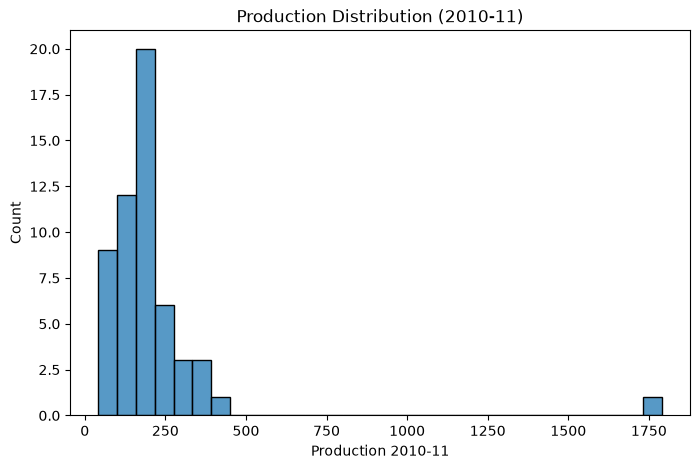

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['Production 2010-11'], bins=30)
plt.title("Production Distribution (2010-11)")
plt.show()

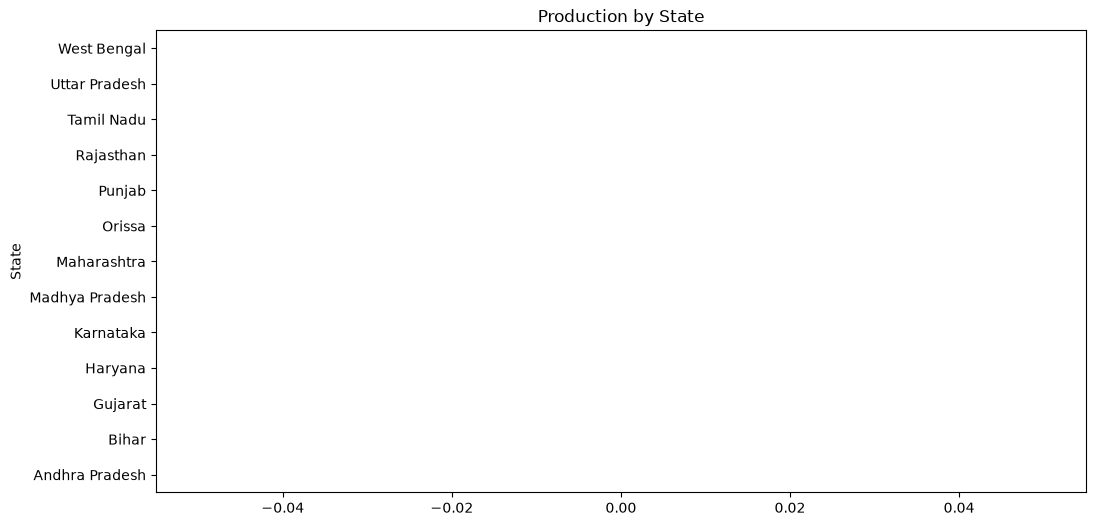

In [44]:
plt.figure(figsize=(12,6))

df.groupby("State")["Production 2010-11"].sum().sort_values().plot(kind="barh")

plt.title("Production by State")
plt.show()

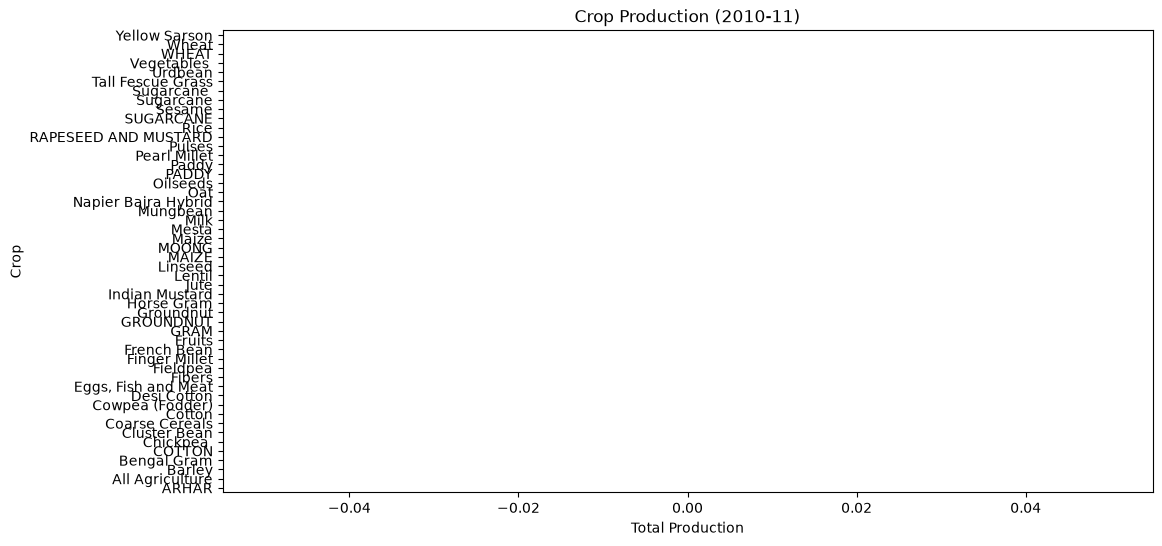

In [45]:
plt.figure(figsize=(12,6))

df.groupby("Crop")["Production 2010-11"].sum().sort_values().plot(kind="barh")

plt.title("Crop Production (2010-11)")
plt.xlabel("Total Production")
plt.show()


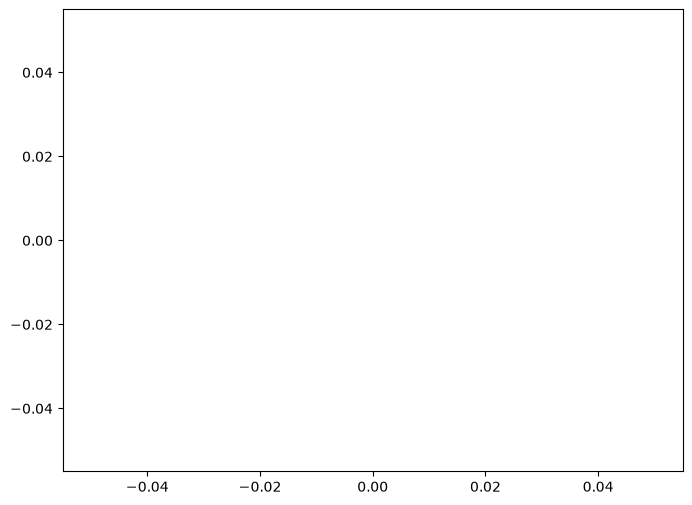

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Cost of Cultivation (`/Hectare) C2',
    y='Production 2010-11'
)

plt.show()

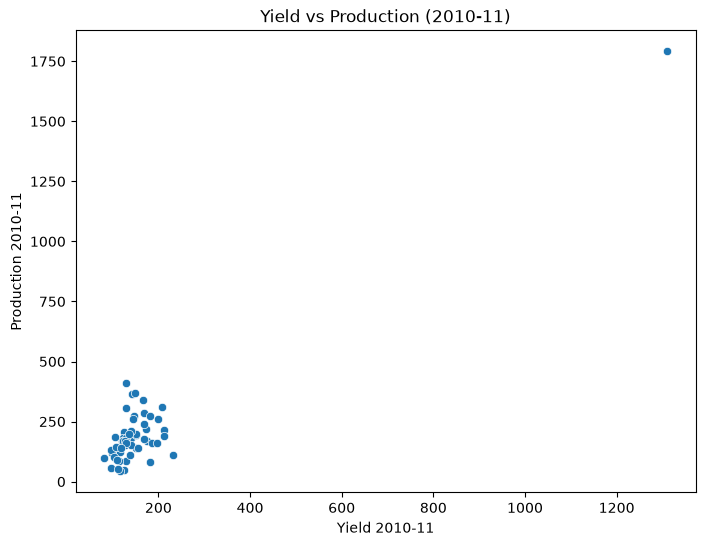

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Yield 2010-11',
    y='Production 2010-11'
)

plt.title("Yield vs Production (2010-11)")
plt.show()


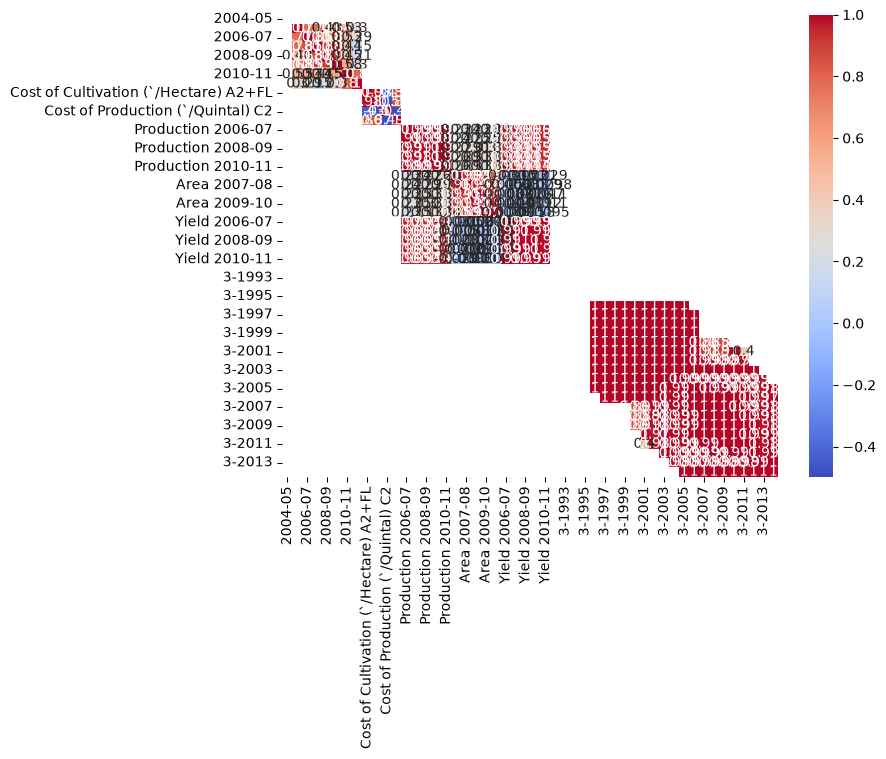

In [49]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [51]:
encoder = LabelEncoder()

categorical_columns = [
    'Crop',
    'Variety',
    'State',
    'Season/ duration in days',
    'Unit',
    'Recommended Zone'
]

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()
    
    df[col] = df[col].fillna('Unknown')
    
    df[col] = encoder.fit_transform(df[col])

In [53]:
target_col = 'Production 2010-11'

columns_to_drop = [
    target_col,
    'Production 2006-07', 'Production 2007-08', 'Production 2008-09', 'Production 2009-10',
    'Area 2006-07', 'Area 2007-08', 'Area 2008-09', 'Area 2009-10', 'Area 2010-11',
    'Yield 2006-07', 'Yield 2007-08', 'Yield 2008-09', 'Yield 2009-10', 'Yield 2010-11',
    'Yield (Quintal/ Hectare) '
]

X = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
y = df[target_col]


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
seen = {}
new_columns = []
for col in X.columns:
    col_stripped = str(col).strip()
    if col_stripped in seen:
        seen[col_stripped] += 1
        new_columns.append(f"{col_stripped}_{seen[col_stripped]}")
    else:
        seen[col_stripped] = 0
        new_columns.append(col_stripped)
X.columns = new_columns

X = pd.get_dummies(X, drop_first=True)

X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
y = pd.to_numeric(y, errors='coerce').fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [60]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test,pred_lr))

print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2 :", r2_score(y_test,pred_lr))

Linear Regression
MAE : 17.5800000004732
RMSE : 58.822308013083855
R2 : -0.09808177163160448


In [61]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree")

print("MAE :", mean_absolute_error(y_test,pred_dt))

print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_dt)))

print("R2 :", r2_score(y_test,pred_dt))

Decision Tree
MAE : 17.58
RMSE : 58.82230801320193
R2 : -0.09808177163601317


In [62]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")

print("MAE :", mean_absolute_error(y_test,pred_rf))

print("RMSE :", np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2 :", r2_score(y_test,pred_rf))

Random Forest
MAE : 12.892024000000001
RMSE : 45.14679348117649
R2 : 0.3531488107549804


In [63]:
models = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_dt),
        r2_score(y_test,pred_rf)
    ]
})

models

,Model,R2 Score
0,Linear Regression,-0.098082
1,Decision Tree,-0.098082
2,Random Forest,0.353149


In [64]:
joblib.dump(rf,"crop_prediction_model.pkl")

['crop_prediction_model.pkl']

In [65]:
model = joblib.load("crop_prediction_model.pkl")

In [66]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Production :", prediction[0])

Predicted Production : 0.0


In [71]:
print("Actual:", y.iloc[0])
print("Predicted:", prediction[0])

Actual: 0.0
Predicted: 0.0
